<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan3_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF 401


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from IPython.display import display

# Setup Tema Visual
sns.set_theme(style='whitegrid', palette='muted')

# Load Data Awal
df = pd.read_csv('/content/sample_data/housing_dirty.csv')

=== LANGKAH 1: EKSPLORASI AWAL ===
1. Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            130 non-null    int64  
 1   luas_m2       112 non-null    float64
 2   harga_juta    113 non-null    float64
 3   kota          130 non-null    object 
 4   kamar         120 non-null    float64
 5   tahun_bangun  130 non-null    int64  
 6   kondisi       130 non-null    object 
dtypes: float64(3), int64(2), object(2)
memory usage: 7.2+ KB

2. Deskripsi Statistik:


,id,luas_m2,harga_juta,kamar,tahun_bangun
count,130.000000,112.000000,1.130000e+02,120.000000,130.000000
mean,65.500000,267.627679,8.856325e+05,3.433333,2062.638462
std,37.671829,885.664181,9.407144e+06,1.776283,701.684043
min,1.000000,-50.000000,-5.000000e+02,1.000000,1890.000000
25%,33.250000,87.050000,3.450000e+02,2.000000,1991.250000
50%,65.500000,193.800000,6.550000e+02,4.000000,2002.000000
75%,97.750000,280.675000,9.550000e+02,5.000000,2011.750000
max,130.000000,9500.000000,1.000000e+08,6.000000,9999.000000



3. Jumlah Missing Values:
id               0
luas_m2         18
harga_juta      17
kota             0
kamar           10
tahun_bangun     0
kondisi          0
dtype: int64


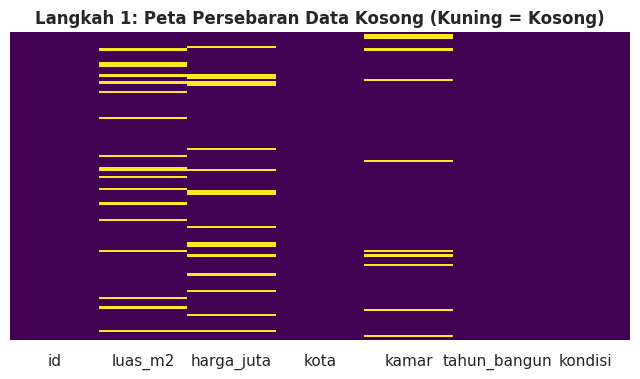

In [20]:
# 1. EKSPLORASI AWAL
print("=== LANGKAH 1: EKSPLORASI AWAL ===")
print("1. Info Dataset:")
df.info()
print("\n2. Deskripsi Statistik:")
display(df.describe())
print("\n3. Jumlah Missing Values:")
print(df.isnull().sum())

# Grafik Langkah 1: Heatmap Missing Values
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Langkah 1: Peta Persebaran Data Kosong (Kuning = Kosong)', fontweight='bold')
plt.show()

In [21]:
# 2. HAPUS DUPLIKAT
print("\n=== LANGKAH 2: HAPUS DUPLIKAT ===")
awal = len(df)
df.drop_duplicates(inplace=True)
akhir = len(df)
print(f"Berhasil menghapus {awal - akhir} baris duplikat. Sisa baris: {akhir}")


=== LANGKAH 2: HAPUS DUPLIKAT ===
Berhasil menghapus 0 baris duplikat. Sisa baris: 130


In [22]:
# 3. NORMALISASI STRING ─────────────────────────────────────
print("\n=== LANGKAH 3: NORMALISASI STRING ===")
# Dictionary untuk menyeragamkan nama kota (mengacu pada data sebelumnya)
city_mapping = {'Ygy': 'Yogyakarta', 'Jogja': 'Yogyakarta', 'Sby': 'Surabaya',
                'Smg': 'Semarang', 'Mksr': 'Makassar', 'Mdn': 'Medan',
                'Bdg': 'Bandung', 'Dpk': 'Depok', 'Jakarta': 'Jakarta'}

df['kota'] = df['kota'].str.strip().str.title().replace(city_mapping)
df['kondisi'] = df['kondisi'].str.strip().str.lower()


=== LANGKAH 3: NORMALISASI STRING ===


Step 3: Data tidak logis telah diubah menjadi NaN.


/tmp/ipykernel_9683/560616292.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='kota', palette='Set2', order=df['kota'].value_counts().index)


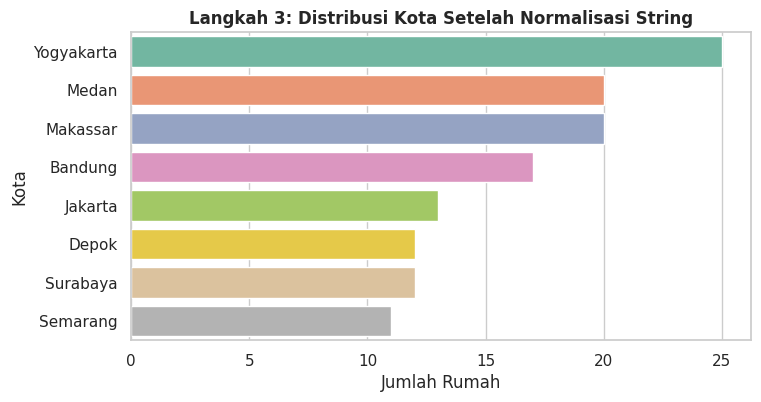

In [23]:
# --- STEP 3: Filter Logika (Ubah data mustahil menjadi NaN) ---
# Langkah ini harus dilakukan SEBELUM mengisi data kosong (Imputasi)
df.loc[df['luas_m2'] <= 0, 'luas_m2'] = np.nan
df.loc[df['tahun_bangun'] > 2026, 'tahun_bangun'] = np.nan
print(f"Step 3: Data tidak logis telah diubah menjadi NaN.")

# Grafik Langkah 3: Distribusi Kota setelah Normalisasi
plt.figure(figsize=(8, 4))
sns.countplot(data=df, y='kota', palette='Set2', order=df['kota'].value_counts().index)
plt.title('Langkah 3: Distribusi Kota Setelah Normalisasi String', fontweight='bold')
plt.xlabel('Jumlah Rumah')
plt.ylabel('Kota')
plt.show()

In [24]:
# 4. IMPUTASI MISSING VALUES
print("\n=== LANGKAH 4: IMPUTASI DATA KOSONG ===")
# Pisahkan kolom numerik dan kategorik
kolom_numerik = df.select_dtypes(include=[np.number]).columns
kolom_kategorik = df.select_dtypes(exclude=[np.number]).columns

# Imputasi Numerik (Median)
for col in kolom_numerik:
    df[col] = df[col].fillna(df[col].median())

# Imputasi Kategorik (Modus)
for col in kolom_kategorik:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Semua data kosong telah diisi dengan Median (Numerik) dan Modus (Kategorik).")


=== LANGKAH 4: IMPUTASI DATA KOSONG ===
Semua data kosong telah diisi dengan Median (Numerik) dan Modus (Kategorik).



=== LANGKAH 5: PENANGANAN OUTLIER ===


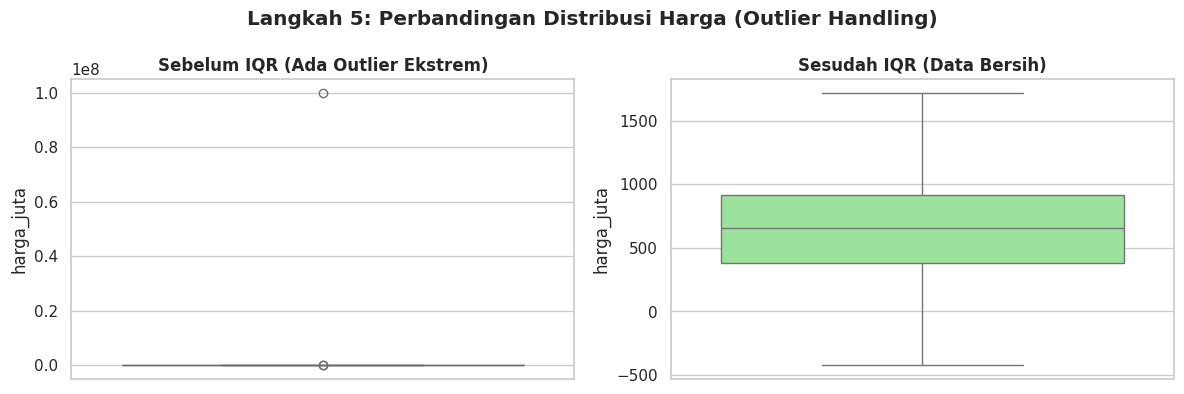

In [25]:
# 5. Penanganan Outlier ---
print("\n=== LANGKAH 5: PENANGANAN OUTLIER ===")
# Simpan data sebelum IQR untuk perbandingan grafik
df_sebelum_outlier = df.copy()

for col in ['harga_juta', 'luas_m2']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # Proses Clipping (Memotong nilai ekstrem)
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

# Grafik Langkah 5: Boxplot Sebelum vs Sesudah Clipping Outlier
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(y=df_sebelum_outlier['harga_juta'], ax=axes[0], color='lightcoral')
axes[0].set_title('Sebelum IQR (Ada Outlier Ekstrem)', fontweight='bold')
sns.boxplot(y=df['harga_juta'], ax=axes[1], color='lightgreen')
axes[1].set_title('Sesudah IQR (Data Bersih)', fontweight='bold')
plt.suptitle('Langkah 5: Perbandingan Distribusi Harga (Outlier Handling)', fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# --- STEP 6: VALIDASI & EKSPOR ---
print("\n=== LANGKAH 6 & 7: VALIDASI & EKSPOR ===")
jumlah_null = df.isnull().sum().sum()
jumlah_duplikat = df.duplicated().sum()

print(f"Total Missing Values Akhir : {jumlah_null}")
print(f"Total Duplikat Akhir       : {jumlah_duplikat}")

# Validasi Ketat
assert jumlah_null == 0, 'Gagal! Masih ada missing values.'
assert jumlah_duplikat == 0, 'Gagal! Masih ada baris duplikat.'

# Ekspor
df.to_csv('housing_clean.csv', index=False)
print("✅ Validasi Sukses! Data diekspor ke 'housing_clean.csv'")


=== LANGKAH 6 & 7: VALIDASI & EKSPOR ===
Total Missing Values Akhir : 0
Total Duplikat Akhir       : 0
✅ Validasi Sukses! Data diekspor ke 'housing_clean.csv'


In [27]:
# ── LANGKAH 8: MENGAKSES API JSONPLACEHOLDER
print("\n=== LANGKAH 8: MENGAMBIL DATA DARI API EXTERNAL ===")
# Mengambil data dummy users dari JSONPlaceholder
url_api = "https://jsonplaceholder.typicode.com/users"
response = requests.get(url_api)

if response.status_code == 200:
    data_json = response.json()
    # Mengubah JSON menjadi Pandas DataFrame
    df_api = pd.DataFrame(data_json)

    print("✅ Berhasil menarik data dari API! Berikut 5 data pertamanya:")
    display(df_api[['id', 'name', 'email', 'phone']].head())
else:
    print(f"Gagal mengambil data. Kode Status: {response.status_code}")


=== LANGKAH 8: MENGAMBIL DATA DARI API EXTERNAL ===
✅ Berhasil menarik data dari API! Berikut 5 data pertamanya:


,id,name,email,phone
0,1,Leanne Graham,Sincere@april.biz,1-770-736-8031 x56442
1,2,Ervin Howell,Shanna@melissa.tv,010-692-6593 x09125
2,3,Clementine Bauch,Nathan@yesenia.net,1-463-123-4447
3,4,Patricia Lebsack,Julianne.OConner@kory.org,493-170-9623 x156
4,5,Chelsey Dietrich,Lucio_Hettinger@annie.ca,(254)954-1289
